In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load Dataset
df = pd.read_csv("Titanic-Dataset.csv") 

#Display first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
#Problem set:- Identify the rat of survival 

In [4]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
print(df.shape)

(891, 12)


In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
df.describe() #only the features that have numerical value

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df.isnull().sum() #isnull object of the pandas lib to find the null values then fillnull to fill the values

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
#if any column has more than 60% empty value in that case drop that from dataframe since it isn't useful for prediction
# label encoder converts non numerical into numerical
# for age - understand the datatype of age, (float64), then we can fill the value with mean [df.describe()] or fill the value with median
#for embark[label encoder [0,1,2] you will have to fill the value with mode

In [11]:
#visualization of missing value


In [12]:
#handle missing values
df["Age"].fillna(df["Age"].median(), inplace=True)

C:\Users\SHUSHOBHITA\AppData\Local\Temp\ipykernel_49748\462062712.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)


In [13]:
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

C:\Users\SHUSHOBHITA\AppData\Local\Temp\ipykernel_49748\122844256.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)


In [14]:
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [15]:
df.drop("Cabin", axis=1, inplace=True)

In [16]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

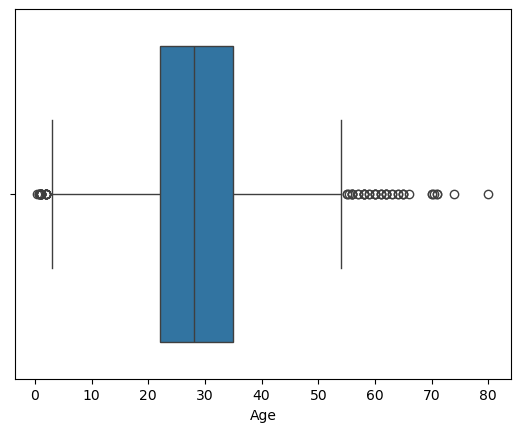

In [18]:
sns.boxplot(x=df["Age"])
plt.show()

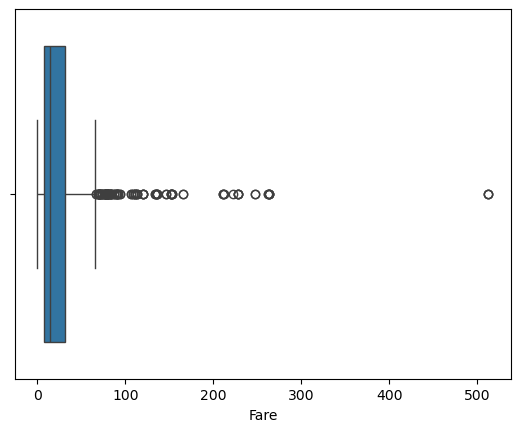

In [19]:
sns.boxplot(x=df["Fare"])
plt.show()

In [20]:
#Removing Outliers using IQR method
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3-Q1

lower = Q1 -1.5*IQR
upper = Q3 +1.5*IQR

df = df[(df["Fare"]>=lower) & (df["Fare"] <=upper)]

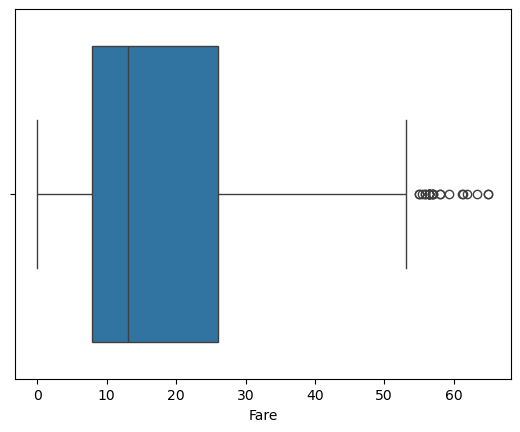

In [21]:
sns.boxplot(x=df["Fare"])
plt.show()

In [22]:
#Data Encoding
df["Sex"].unique()

array(['male', 'female'], dtype=object)

In [23]:
#hot encoding, label encoder, label scaling, pca-principle component analysis (only used for feature selection)

df["Sex"] = df["Sex"].replace("male", 0)
df["Sex"] = df["Sex"].replace("female", 1)

C:\Users\SHUSHOBHITA\AppData\Local\Temp\ipykernel_49748\2589314398.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Sex"] = df["Sex"].replace("female", 1)


In [24]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",0,28.0,0,0,330877,8.4583,Q


In [25]:
df["Embarked"].unique()

array(['S', 'Q', 'C'], dtype=object)

In [26]:
df["Embarked"] = df["Embarked"].replace("S", 0)
df["Embarked"] = df["Embarked"].replace("C", 1)
df["Embarked"] = df["Embarked"].replace("Q", 2)

C:\Users\SHUSHOBHITA\AppData\Local\Temp\ipykernel_49748\3748634860.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Embarked"] = df["Embarked"].replace("Q", 2)


In [27]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0
5,6,0,3,"Moran, Mr. James",0,28.0,0,0,330877,8.4583,2


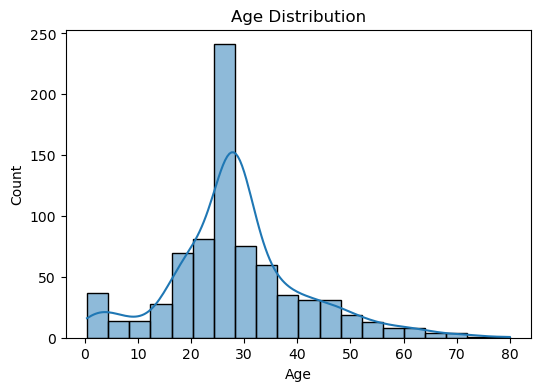

In [28]:
#Univariate Analysis
plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution")
plt.show()

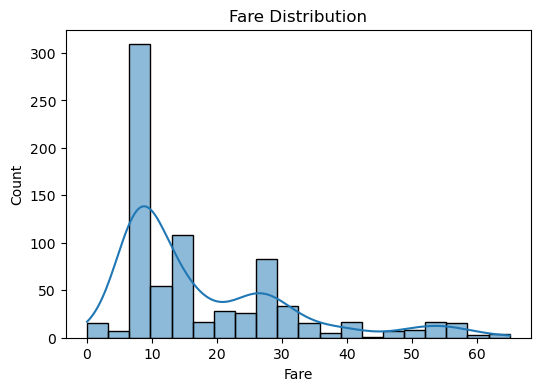

In [29]:
#Univariate Analysis
plt.figure(figsize=(6,4))
sns.histplot(df["Fare"], bins=20, kde=True)

plt.title("Fare Distribution")
plt.show()

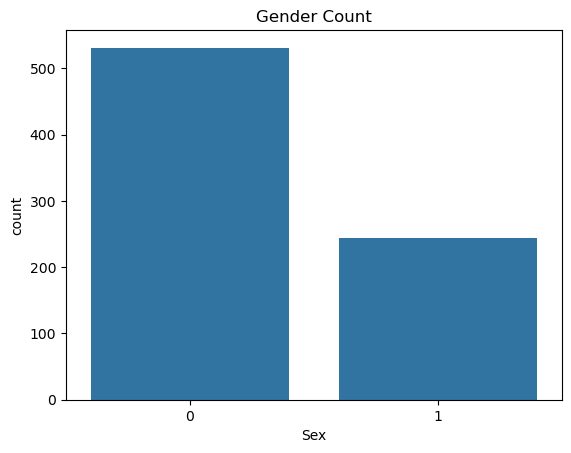

In [30]:
sns.countplot(x="Sex", data=df)
plt.title("Gender Count")
plt.show()

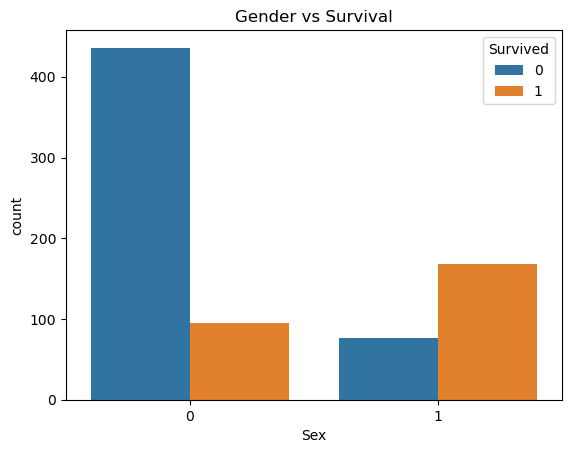

In [31]:
#Bivariate Analysis
sns.countplot(x="Sex", hue = "Survived", data=df)
plt.title("Gender vs Survival")
plt.show()

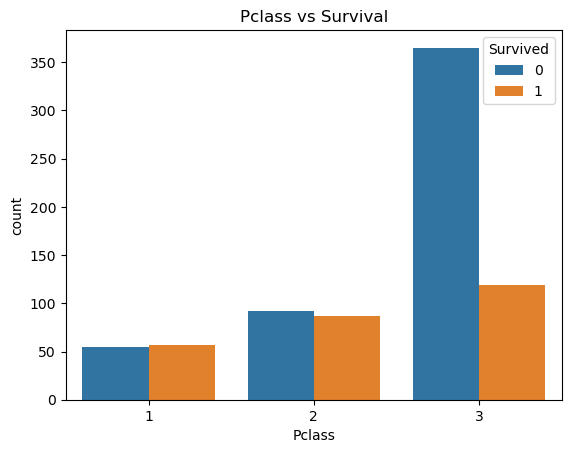

In [32]:
sns.countplot(x="Pclass", hue = "Survived", data=df)
plt.title("Pclass vs Survival")
plt.show()

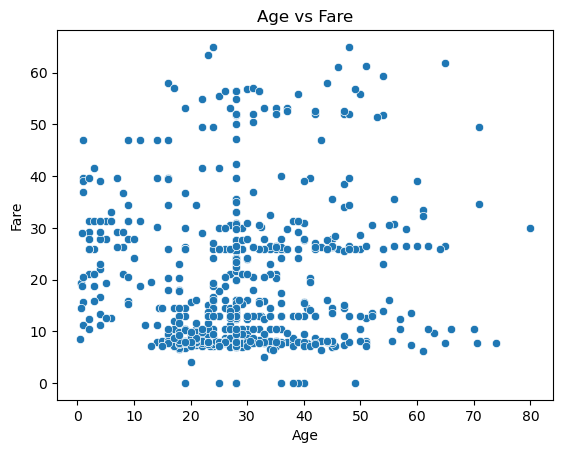

In [33]:
sns.scatterplot(x="Age", y="Fare", data=df)

plt.title("Age vs Fare")
plt.show()

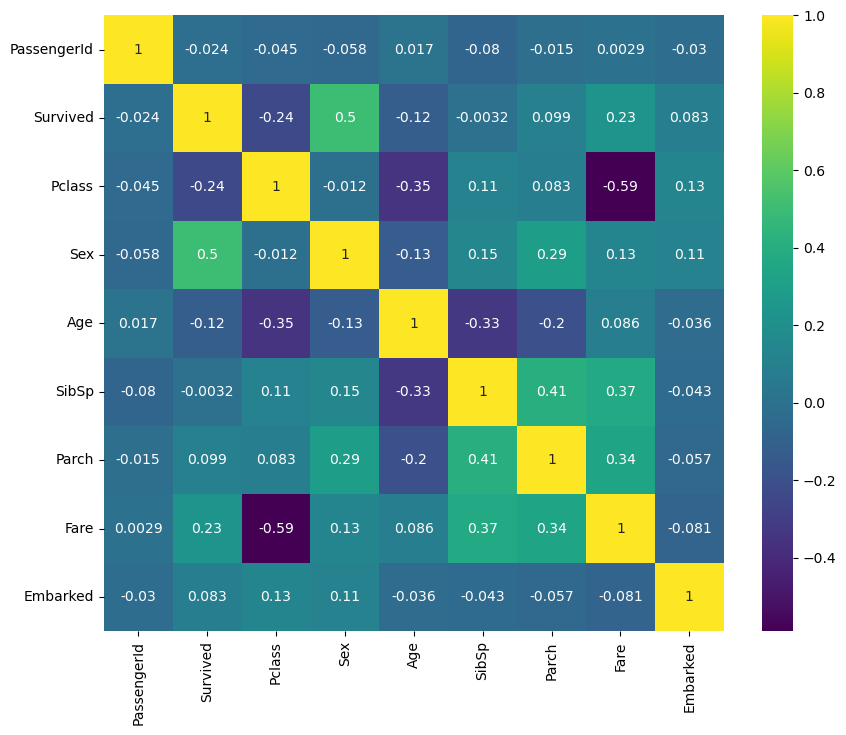

In [34]:
#multivariant
#exact range of correlation -1, 0, +1 [strong negative, null or dead relation, strong positive]

plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='viridis')

plt.show()

#viridis, plasma, inferno, magma, cividis, YlGnBu

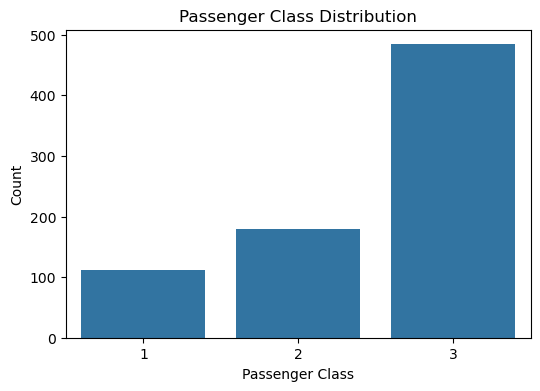

In [35]:
#Count Plot (Categorical Data)
plt.figure(figsize=(6,4))
sns.countplot(x="Pclass", data=df)

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

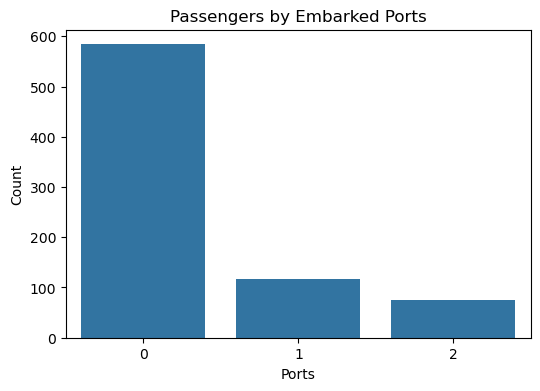

In [36]:
plt.figure(figsize=(6,4))
sns.countplot(x="Embarked", data=df)

plt.title("Passengers by Embarked Ports")
plt.xlabel("Ports")
plt.ylabel("Count")
plt.show()

In [37]:
#Feature Scaling
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [39]:
X = X.drop(["PassengerId", "Name", "Ticket"], axis=1)

In [41]:
#Standard Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X[["Age", "Fare"]] = scaler.fit_transform(X[["Age", "Fare"]])

In [42]:
X.head(15)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,-0.528321,1,0,-0.779117,0
2,3,1,-0.215182,0,0,-0.729373,0
3,1,1,0.489381,1,0,2.599828,0
4,3,0,0.489381,0,0,-0.720161,0
5,3,0,-0.058613,0,0,-0.690071,2
6,1,0,1.976792,0,0,2.508630,0
7,3,0,-2.094017,3,1,0.239725,0
8,3,1,-0.136897,0,2,-0.492935,0
9,2,1,-1.154600,1,0,0.902677,1
10,3,1,-1.937447,1,1,-0.082693,0


In [43]:
#Train Test Split
from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state=42)

In [44]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (620, 7)
Testing Data: (155, 7)


In [46]:
print(X_train.head())

     Pclass  Sex       Age  SibSp  Parch      Fare  Embarked
147       3    1 -1.546024      2      2  1.219877         0
868       3    0 -0.058613      0      0 -0.613302         0
60        3    0 -0.528321      0      0 -0.780650         1
468       3    0 -0.058613      0      0 -0.744112         2
777       3    1 -1.859163      0      0 -0.394057         0
